# Loan Approval Prediction

## 1. Problem Definition

### Business objective

The objective is to build a machine-learning model that predicts whether a loan
application is likely to be approved based on the applicant's financial and
demographic information.

The model is intended as a decision-support and educational tool. It should not
make autonomous lending decisions.

### Machine-learning task

This is a supervised binary-classification problem.

- Target column: `Loan_Status`
- Positive class: `Y` — loan approved
- Negative class: `N` — loan not approved
- Unit of observation: one loan application

### Evaluation priorities

Because the target classes may be imbalanced, accuracy alone will not be used.

The model will be evaluated using:

1. Macro F1-score as the primary model-comparison metric
2. Recall and precision for both approval classes
3. ROC-AUC
4. Confusion matrix
5. Accuracy as a supporting metric

### Error considerations

- False approval: the model predicts approval for an application historically
  recorded as not approved.
- False rejection: the model predicts rejection for an application historically
  recorded as approved.

Both errors will be reported separately rather than hidden inside overall
accuracy.

### Important limitation

`Loan_Status` records historical approval decisions. It does not indicate whether
a borrower eventually repaid or defaulted on the loan. Therefore, this model
learns historical approval patterns—not true credit risk or repayment ability.

Demographic variables may also reproduce historical bias. Fairness checks will
be performed before considering any practical use.


In [139]:
import sys
from pathlib import Path
import json
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning libraries
import joblib
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import optuna
import sklearn



import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    GridSearchCV,
    cross_validate,
    StratifiedKFold,
    train_test_split
)

#Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)


warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_TRIALS = 20

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Finance.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"Python:       {platform.python_version()}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"LightGBM:     {lgb.__version__}")
print(f"Optuna:       {optuna.__version__}")
print(f"MLflow:       {mlflow.__version__}")
print(f"Data path:    {DATA_PATH}")

Python:       3.11.15
scikit-learn: 1.9.0
LightGBM:     4.7.0
Optuna:       4.9.0
MLflow:       3.14.0
Data path:    c:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Loan Approval Predcitor (PJ 5)\loan_approval_predictor\data\raw\Finance.csv


# Data Validation

In [ ]:
df_raw=pd.read_csv(DATA_PATH)

In [4]:
df_raw.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Dataset shape: 614 rows × 13 columns


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
schema_summary = pd.DataFrame({
    "data_type": df_raw.dtypes.astype(str),
    "non_missing": df_raw.notna().sum(),
    "missing": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean().mul(100).round(2),
    "unique_values": df_raw.nunique(dropna=True),
})

schema_summary.index.name = "column"
display(schema_summary)

,data_type,non_missing,missing,missing_percent,unique_values
column,,,,,
Loan_ID,object,614,0,0.00,614
Gender,object,601,13,2.12,2
Married,object,611,3,0.49,2
Dependents,object,599,15,2.44,4
Education,object,614,0,0.00,2
Self_Employed,object,582,32,5.21,2
ApplicantIncome,int64,614,0,0.00,505
CoapplicantIncome,float64,614,0,0.00,287
LoanAmount,float64,592,22,3.58,203


In [11]:
df_raw.describe(include="all")

column,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [12]:
TARGET = "Loan_Status"
ID_COLUMN = "Loan_ID"

EXPECTED_COLUMNS = {
    "Loan_ID",
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area",
    "Loan_Status",
}

missing_columns = sorted(EXPECTED_COLUMNS - set(df_raw.columns))
unexpected_columns = sorted(set(df_raw.columns) - EXPECTED_COLUMNS)

print(f"Missing columns: {missing_columns}")
print(f"Unexpected columns: {unexpected_columns}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print(f"Duplicate Loan IDs: {df_raw[ID_COLUMN].duplicated().sum()}")
print(f"Missing target values: {df_raw[TARGET].isna().sum()}")
print(f"Target values: {sorted(df_raw[TARGET].dropna().unique())}")

Missing columns: []
Unexpected columns: []
Duplicate rows: 0
Duplicate Loan IDs: 0
Missing target values: 0
Target values: ['N', 'Y']


# 4. Data-Quality Audit and Initial Exploration

This section examines missing values, duplicates, target balance, category
consistency, numerical distributions, and potential outliers.

No preprocessing decisions are applied to the raw dataset at this stage.

## 4.1 Check Data quality

In [13]:
quality_ckecks=pd.Series({
    "rows":len(df_raw),
    "columns":df_raw.shape[1],
    "Completely_empty_rows":df_raw.isna().all(axis=1).sum(),
    "duplicate_rows":df_raw.duplicated().sum(),
    "duplicate_Loan_IDs":df_raw[ID_COLUMN].duplicated().sum(),
    "missing_loan_id":df_raw[ID_COLUMN].isna().sum(),
    "missing_target_values":df_raw[TARGET].isna().sum(),
    "negative_applicant_income": (
        df_raw["ApplicantIncome"].dropna() < 0
    ).sum(),
    "negative_coapplicant_income": (
        df_raw["CoapplicantIncome"].dropna() < 0
    ).sum(),
    "non_positive_loan_amount": (
        df_raw["LoanAmount"].dropna() <= 0
    ).sum(),
    "non_positive_loan_term": (
        df_raw["Loan_Amount_Term"].dropna() <= 0
    ).sum(),
    "invalid_credit_history": (
        ~df_raw["Credit_History"].dropna().isin([0, 1])
    ).sum()
})

display(quality_ckecks.to_frame(name="value"))

,value
rows,614
columns,13
Completely_empty_rows,0
duplicate_rows,0
duplicate_Loan_IDs,0
missing_loan_id,0
missing_target_values,0
negative_applicant_income,0
negative_coapplicant_income,0
non_positive_loan_amount,0


## 4.2 Examine Missing Value

In [16]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df_raw.isna().sum(),
        "missing_percent": df_raw.isna().mean().mul(100),
    })
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

,missing_count,missing_percent
column,,
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


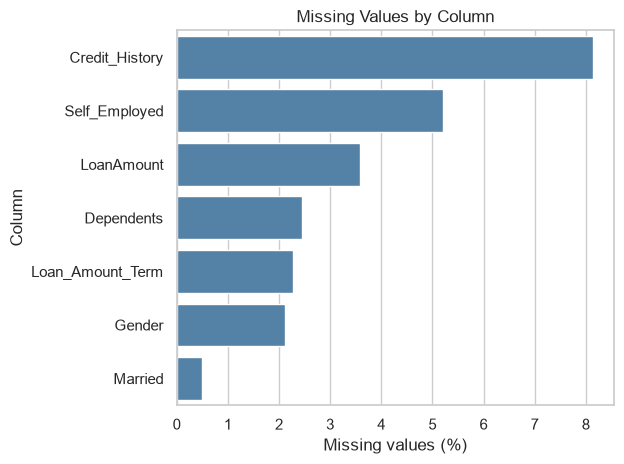

In [21]:
# Visualize missing values
# Prepare explicitly named plotting data
missing_plot_data = (
    missing_summary
    .rename_axis("column")
    .reset_index()
)

if not missing_plot_data.empty:
    ax = sns.barplot(
        data=missing_plot_data,
        x="missing_percent",
        y="column",
        color="steelblue",
    )

    ax.set(
        title="Missing Values by Column",
        xlabel="Missing values (%)",
        ylabel="Column",
    )

    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

## 4.3 Examine the Target Distribution


In [22]:
target_summary = (
    df_raw[TARGET]
    .value_counts(dropna=False)
    .rename_axis("loan_status")
    .to_frame("count")
)

target_summary["percent"] = (
    target_summary["count"]
    .div(len(df_raw))
    .mul(100)
)

display(target_summary)

,count,percent
loan_status,,
Y,422,68.729642
N,192,31.270358


## 4.4.1 Categorical EDA

In [24]:
categorical_eda_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area",
    "Loan_Amount_Term",
]

In [25]:
categorical_summaries = []

for column in categorical_eda_columns:
    # Convert to strings temporarily for display and preserve missing values
    display_values = (
        df_raw[column]
        .astype("string")
        .fillna("Missing")
    )

    column_summary = (
        display_values
        .value_counts(dropna=False)
        .rename_axis("category")
        .reset_index(name="count")
    )

    column_summary["percent"] = (
        column_summary["count"]
        .div(len(df_raw))
        .mul(100)
        .round(2)
    )

    column_summary.insert(0, "column", column)
    categorical_summaries.append(column_summary)

categorical_distribution = pd.concat(
    categorical_summaries,
    ignore_index=True,
)

display(categorical_distribution)

,column,category,count,percent
0,Gender,Male,489,79.64
1,Gender,Female,112,18.24
2,Gender,Missing,13,2.12
3,Married,Yes,398,64.82
4,Married,No,213,34.69
5,Married,Missing,3,0.49
6,Dependents,0,345,56.19
7,Dependents,1,102,16.61
8,Dependents,2,101,16.45
9,Dependents,3+,51,8.31


In [26]:
for column in categorical_eda_columns:
    print(f"\n{column}")
    
    display(
        categorical_distribution.loc[
            categorical_distribution["column"].eq(column)
        ]
    )


Gender


,column,category,count,percent
0,Gender,Male,489,79.64
1,Gender,Female,112,18.24
2,Gender,Missing,13,2.12



Married


,column,category,count,percent
3,Married,Yes,398,64.82
4,Married,No,213,34.69
5,Married,Missing,3,0.49



Dependents


...

,column,category,count,percent
16,Credit_History,1.0,475,77.36
17,Credit_History,0.0,89,14.5
18,Credit_History,Missing,50,8.14



Property_Area


,column,category,count,percent
19,Property_Area,Semiurban,233,37.95
20,Property_Area,Urban,202,32.9
21,Property_Area,Rural,179,29.15



Loan_Amount_Term


,column,category,count,percent
22,Loan_Amount_Term,360.0,512,83.39
23,Loan_Amount_Term,180.0,44,7.17
24,Loan_Amount_Term,480.0,15,2.44
25,Loan_Amount_Term,Missing,14,2.28
26,Loan_Amount_Term,300.0,13,2.12
27,Loan_Amount_Term,84.0,4,0.65
28,Loan_Amount_Term,240.0,4,0.65
29,Loan_Amount_Term,120.0,3,0.49
30,Loan_Amount_Term,60.0,2,0.33
31,Loan_Amount_Term,36.0,2,0.33


In [29]:
TARGET = "Loan_Status"

POSITIVE_LABEL = "Y"  # Approved
NEGATIVE_LABEL = "N"  # Rejected

In [30]:
categorical_summaries = []

for column in categorical_eda_columns:
    category_values = (
        df_raw[column]
        .astype("string")
        .fillna("Missing")
        .rename("category")
    )

    target_values = (
        df_raw[TARGET]
        .astype("string")
        .rename(TARGET)
    )

    # Count approved and rejected applications per category
    outcome_counts = pd.crosstab(
        category_values,
        target_values,
        dropna=False,
    )

    # Ensure both target columns exist
    outcome_counts = outcome_counts.reindex(
        columns=[NEGATIVE_LABEL, POSITIVE_LABEL],
        fill_value=0,
    )

    column_summary = (
        outcome_counts
        .rename(columns={
            NEGATIVE_LABEL: "rejected_count",
            POSITIVE_LABEL: "approved_count",
        })
        .reset_index()
    )

    column_summary["total_count"] = (
        column_summary["rejected_count"]
        + column_summary["approved_count"]
    )

    column_summary["dataset_percent"] = (
        column_summary["total_count"]
        .div(len(df_raw))
        .mul(100)
        .round(2)
    )

    column_summary["approval_rate"] = (
        column_summary["approved_count"]
        .div(column_summary["total_count"])
        .mul(100)
        .round(2)
    )

    column_summary["rejection_rate"] = (
        column_summary["rejected_count"]
        .div(column_summary["total_count"])
        .mul(100)
        .round(2)
    )

    column_summary.insert(0, "column", column)

    column_summary = column_summary.sort_values(
        "total_count",
        ascending=False,
    )

    categorical_summaries.append(column_summary)

categorical_distribution = pd.concat(
    categorical_summaries,
    ignore_index=True,
)

display(categorical_distribution)

Loan_Status,column,category,rejected_count,approved_count,total_count,dataset_percent,approval_rate,rejection_rate
0,Gender,Male,150,339,489,79.64,69.33,30.67
1,Gender,Female,37,75,112,18.24,66.96,33.04
2,Gender,Missing,5,8,13,2.12,61.54,38.46
3,Married,Yes,113,285,398,64.82,71.61,28.39
4,Married,No,79,134,213,34.69,62.91,37.09
5,Married,Missing,0,3,3,0.49,100.00,0.00
6,Dependents,0,107,238,345,56.19,68.99,31.01
7,Dependents,1,36,66,102,16.61,64.71,35.29
8,Dependents,2,25,76,101,16.45,75.25,24.75
9,Dependents,3+,18,33,51,8.31,64.71,35.29


## 4.6 Examine Numerical Distribution

In [31]:
continuous_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
]

numeric_summary = df_raw[continuous_columns].describe().T
numeric_summary["median"] = df_raw[continuous_columns].median()
numeric_summary["skewness"] = df_raw[continuous_columns].skew()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness
column,,,,,,,,,,
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0,3812.5,6.539513
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0,1188.5,7.491531
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0,128.0,2.677552
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0,360.0,-2.362414


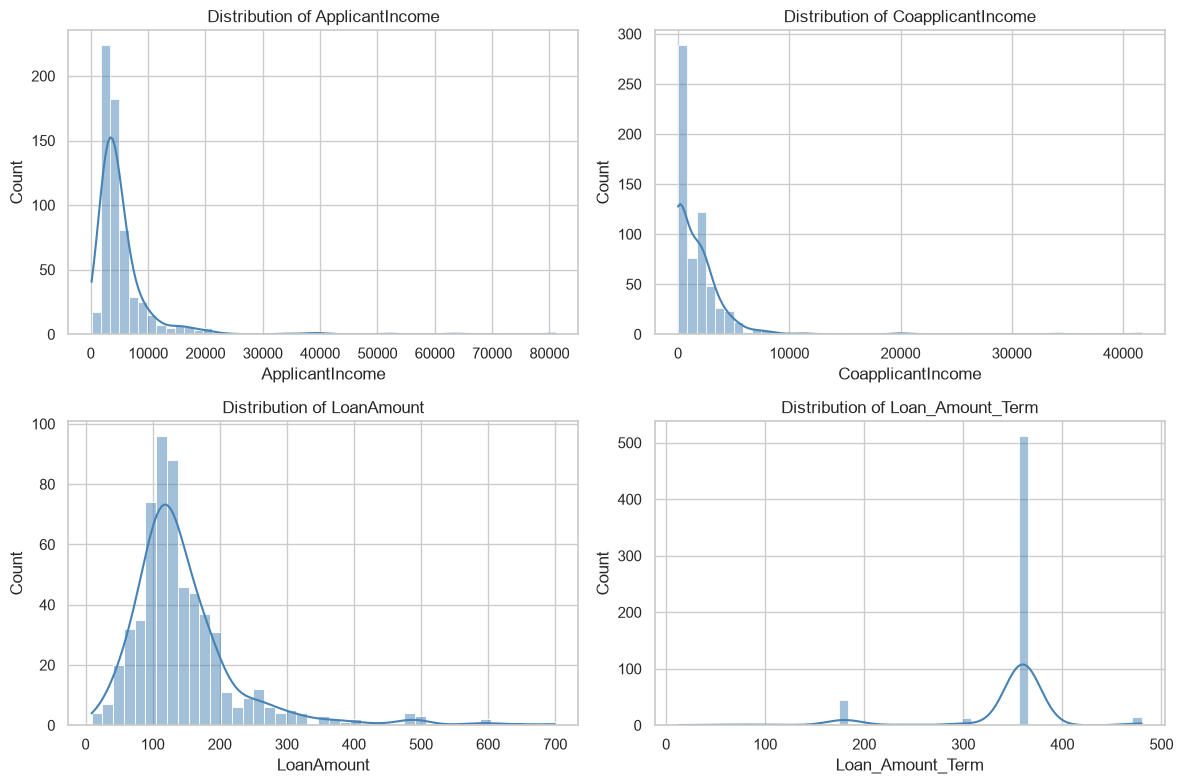

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for column, ax in zip(continuous_columns, axes.flat):
    sns.histplot(
        data=df_raw,
        x=column,
        kde=True,
        ax=ax,
        color="steelblue",
    )
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

## 4.6 Identify Potential Outlier

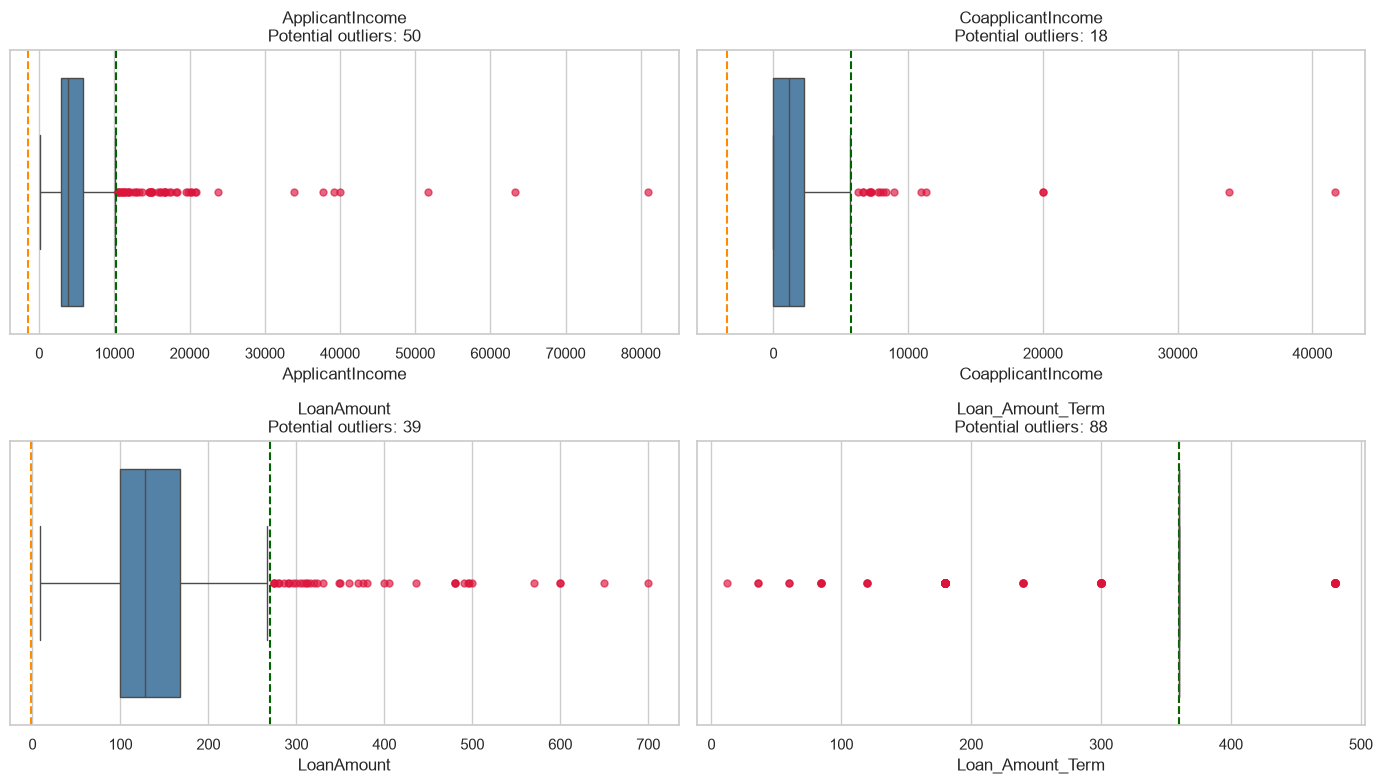

In [35]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
)

axes = axes.flatten()

outlier_style = {
    "marker": "o",
    "markerfacecolor": "crimson",
    "markeredgecolor": "crimson",
    "markersize": 5,
    "alpha": 0.65,
}

for ax, column in zip(axes, continuous_columns):
    values = df_raw[column].dropna()

    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr = third_quartile - first_quartile

    lower_bound = first_quartile - (1.5 * iqr)
    upper_bound = third_quartile + (1.5 * iqr)

    outlier_count = (
        (values < lower_bound) |
        (values > upper_bound)
    ).sum()

    sns.boxplot(
        data=df_raw,
        x=column,
        ax=ax,
        color="steelblue",
        showfliers=True,
        flierprops=outlier_style,
    )

    # Display the calculated IQR boundaries
    ax.axvline(
        lower_bound,
        color="darkorange",
        linestyle="--",
        linewidth=1.5,
        label="Lower IQR boundary",
    )

    ax.axvline(
        upper_bound,
        color="darkgreen",
        linestyle="--",
        linewidth=1.5,
        label="Upper IQR boundary",
    )

    ax.set_title(
        f"{column}\nPotential outliers: {outlier_count}"
    )
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

In [34]:
outlier_summary = calculate_iqr_outliers(
    df_raw,
    continuous_columns,
)

display(outlier_summary)

,column,lower_bound,upper_bound,potential_outliers,outlier_percent
0,ApplicantIncome,-1498.750,10171.250,50,8.143322
1,CoapplicantIncome,-3445.875,5743.125,18,2.931596
2,LoanAmount,-2.000,270.000,39,6.587838
3,Loan_Amount_Term,360.000,360.000,88,14.666667


# 5. Stratified Train-Test Split

A stratified holdout set is created before preprocessing. Stratification preserves
the approval/rejection proportions in both datasets.

The test set will remain untouched during EDA, preprocessing decisions, model
comparison, hyperparameter tuning, and threshold selection.

## 5.1 Split the Raw Observation

In [37]:
train_df, test_df = train_test_split(
    df_raw,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_raw[TARGET],
)

train_df=train_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)

print(f"Training observations: {len(train_df)}")
print(f"Test observations:     {len(test_df)}")

Training observations: 491
Test observations:     123


## 5.2 Verify the Split

In [38]:
overlapping_ids = set(train_df[ID_COLUMN]).intersection(test_df[ID_COLUMN])

if overlapping_ids:
    raise ValueError(
        f"Train-test leakage detected: {len(overlapping_ids)} IDs overlap."
    )

if len(train_df) + len(test_df) != len(df_raw):
    raise ValueError("Some observations were lost during splitting.")

print("No Loan_ID overlap between training and test sets.")
print("All observations were preserved.")

No Loan_ID overlap between training and test sets.
All observations were preserved.


## 5.3 Confirm Class startification

In [39]:
def class_distribution(data, split_name):
    summary = (
        data[TARGET]
        .value_counts()
        .reindex([NEGATIVE_LABEL, POSITIVE_LABEL])
        .rename("count")
        .to_frame()
    )

    summary["percent"] = (
        summary["count"]
        .div(len(data))
        .mul(100)
        .round(2)
    )

    summary.insert(0, "dataset", split_name)
    return summary.reset_index(names=TARGET)

In [40]:
split_distribution = pd.concat(
    [
        class_distribution(train_df, "Training"),
        class_distribution(test_df, "Test"),
    ],
    ignore_index=True,
)

display(split_distribution)

,Loan_Status,dataset,count,percent
0,N,Training,154,31.36
1,Y,Training,337,68.64
2,N,Test,38,30.89
3,Y,Test,85,69.11


## 5.4 Separate Features and Target

In [41]:
TARGET_MAPPING = {
    NEGATIVE_LABEL: 0,
    POSITIVE_LABEL: 1,
}

X_train = train_df.drop(
    columns=[TARGET, ID_COLUMN]
).copy()

y_train = (
    train_df[TARGET]
    .map(TARGET_MAPPING)
    .astype("int8")
)

X_test = test_df.drop(
    columns=[TARGET, ID_COLUMN]
).copy()

y_test = (
    test_df[TARGET]
    .map(TARGET_MAPPING)
    .astype("int8")
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (491, 11)
y_train shape: (491,)
X_test shape:  (123, 11)
y_test shape:  (123,)


## 5.4 Sepate Features and target

In [42]:
TARGET_MAPPING = {
    NEGATIVE_LABEL: 0,
    POSITIVE_LABEL: 1,
}

X_train = train_df.drop(
    columns=[TARGET, ID_COLUMN]
).copy()

y_train = (
    train_df[TARGET]
    .map(TARGET_MAPPING)
    .astype("int8")
)

X_test = test_df.drop(
    columns=[TARGET, ID_COLUMN]
).copy()

y_test = (
    test_df[TARGET]
    .map(TARGET_MAPPING)
    .astype("int8")
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (491, 11)
y_train shape: (491,)
X_test shape:  (123, 11)
y_test shape:  (123,)


## 6 Build A lekage Safe preprocessing Pipeline

####  Leakage-Safe Preprocessing

Preprocessing is defined as a reusable Scikit-learn transformer. All imputation,
scaling, and category learning will occur only during model fitting.

Right-skewed monetary variables receive a logarithmic transformation. Categorical
variables are one-hot encoded while allowing previously unseen categories.

In [45]:
from sklearn.base import clone
from sklearn.preprocessing import FunctionTransformer

In [46]:
skewed_numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

standard_numeric_features = [
    "Loan_Amount_Term"]

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area",
]

### 6.3 Validate Feature Assignments

In [47]:
configured_features = (
    skewed_numeric_features
    + standard_numeric_features
    + categorical_features
)

duplicate_feature_assignments = {
    feature
    for feature in configured_features
    if configured_features.count(feature) > 1
}

missing_from_training_data = (
    set(configured_features) - set(X_train.columns)
)

unconfigured_training_features = (
    set(X_train.columns) - set(configured_features)
)

if duplicate_feature_assignments:
    raise ValueError(
        f"Features assigned more than once: "
        f"{sorted(duplicate_feature_assignments)}"
    )

if missing_from_training_data:
    raise ValueError(
        f"Configured features not found in X_train: "
        f"{sorted(missing_from_training_data)}"
    )

if unconfigured_training_features:
    raise ValueError(
        f"Training features not assigned to a transformer: "
        f"{sorted(unconfigured_training_features)}"
    )

print(f"Configured features: {len(configured_features)}")
print("Every training feature has exactly one preprocessing assignment.")

Configured features: 11
Every training feature has exactly one preprocessing assignment.


### 6.4 Create the Numerical Pipeline

In [48]:
skewed_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "log_transformer",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

standard_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

### 6.5 Create the Categorical Pipeline

In [49]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

### 6.6 Combine the transformations

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "skewed_numeric",
            skewed_numeric_pipeline,
            skewed_numeric_features,
        ),
        (
            "standard_numeric",
            standard_numeric_pipeline,
            standard_numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

### 6.7 Preview the transformed training data safely

In [51]:
preview_preprocessor = clone(preprocessor)

X_train_preview = preview_preprocessor.fit_transform(X_train)

transformed_feature_names = (
    preview_preprocessor.get_feature_names_out()
)

X_train_preview = pd.DataFrame(
    X_train_preview,
    columns=transformed_feature_names,
    index=X_train.index,
)

print(f"Original training shape:    {X_train.shape}")
print(f"Transformed training shape: {X_train_preview.shape}")
print(
    "Missing values after preprocessing:",
    int(X_train_preview.isna().sum().sum()),
)

display(X_train_preview.head())

Original training shape:    (491, 11)
Transformed training shape: (491, 21)
Missing values after preprocessing: 0


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,...,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Credit_History_0.0,Credit_History_1.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,-0.430568,-1.087807,-1.896439,0.280691,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.401324,-1.087807,-0.596273,0.280691,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.389494,0.833980,0.298775,0.280691,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.752067,0.800178,-0.269682,-2.486768,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.771773,0.901671,0.298775,0.280691,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [52]:
del X_train_preview
del preview_preprocessor

## 7 establish a Baseline Model

### 7.1 Add the scoring Import

In [53]:
from sklearn.metrics import make_scorer

## 7. Baseline Model

A majority-class DummyClassifier establishes the minimum performance baseline.
It is evaluated using five-fold stratified cross-validation on the training set.

The holdout test set is not used during this process.

In [56]:
cross_validation=StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE)


### 7.3 Define evaluation Metrics

In [57]:
scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "roc_auc": "roc_auc",

    "approval_precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0,
    ),
    "approval_recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0,
    ),
    "rejection_precision": make_scorer(
        precision_score,
        pos_label=0,
        zero_division=0,
    ),
    "rejection_recall": make_scorer(
        recall_score,
        pos_label=0,
        zero_division=0,
    ),
}

### 7.4 Build the Baseline pipeline

In [58]:
baseline_pipeline=Pipeline(
    steps=[("preprocessor",clone(preprocessor)),
           ("model",DummyClassifier(strategy="most_frequent"))
           ]
          
)

### 7.5 Run Crosss-validation

In [59]:
baseline_cv_results = cross_validate(
    estimator=baseline_pipeline,
    X=X_train,
    y=y_train,
    cv=cross_validation,
    scoring=scoring_metrics,
    return_train_score=True,
    n_jobs=-1,
)

In [60]:
baseline_fold_scores = pd.DataFrame({
    metric_name: baseline_cv_results[f"test_{metric_name}"]
    for metric_name in scoring_metrics
})

baseline_fold_scores.index = [
    f"Fold {fold_number}"
    for fold_number in range(1, N_SPLITS + 1)
]

display(baseline_fold_scores.round(3))

,accuracy,balanced_accuracy,macro_f1,roc_auc,approval_precision,approval_recall,rejection_precision,rejection_recall
Fold 1,0.687,0.5,0.407,0.5,0.687,1.0,0.0,0.0
Fold 2,0.694,0.5,0.410,0.5,0.694,1.0,0.0,0.0
Fold 3,0.684,0.5,0.406,0.5,0.684,1.0,0.0,0.0
Fold 4,0.684,0.5,0.406,0.5,0.684,1.0,0.0,0.0
Fold 5,0.684,0.5,0.406,0.5,0.684,1.0,0.0,0.0


In [61]:
baseline_summary = (
    baseline_fold_scores
    .agg(["mean", "std"])
    .T
    .rename(columns={
        "mean": "cv_mean",
        "std": "cv_std",
    })
    .sort_values("cv_mean", ascending=False)
)

display(baseline_summary.round(3))

,cv_mean,cv_std
approval_recall,1.000,0.000
accuracy,0.686,0.004
approval_precision,0.686,0.004
balanced_accuracy,0.500,0.000
roc_auc,0.500,0.000
macro_f1,0.407,0.002
rejection_precision,0.000,0.000
rejection_recall,0.000,0.000


### 7.6 Save Baseline Result for Later Comparison

In [62]:
model_comparison_results = []

model_comparison_results.append({
    "model": "Dummy Classifier",
    **{
        f"{metric}_mean": baseline_fold_scores[metric].mean()
        for metric in scoring_metrics
    },
    **{
        f"{metric}_std": baseline_fold_scores[metric].std()
        for metric in scoring_metrics
    },
})

### 7.7 Log the baseline for ML flow

In [63]:
MLFLOW_DIRECTORY = PROJECT_ROOT / "mlruns"
MLFLOW_EXPERIMENT = "loan-approval-predictor"

mlflow.set_tracking_uri(
    MLFLOW_DIRECTORY.resolve().as_uri()
)

mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name="dummy-classifier-baseline"):
    mlflow.log_param("model", "DummyClassifier")
    mlflow.log_param("strategy", "most_frequent")
    mlflow.log_param("cv_folds", N_SPLITS)
    mlflow.log_param("random_state", RANDOM_STATE)

    for metric in scoring_metrics:
        mlflow.log_metric(
            f"cv_{metric}_mean",
            baseline_fold_scores[metric].mean(),
        )
        mlflow.log_metric(
            f"cv_{metric}_std",
            baseline_fold_scores[metric].std(),
        )

print("Baseline results logged to MLflow.")

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

In [64]:
MLFLOW_DIRECTORY = PROJECT_ROOT / "mlruns"

mlflow.set_tracking_uri(
    MLFLOW_DIRECTORY.resolve().as_uri()
)

In [65]:
MLFLOW_DATABASE_PATH = (
    PROJECT_ROOT / "mlflow.db"
).resolve()

MLFLOW_TRACKING_URI = (
    f"sqlite:///{MLFLOW_DATABASE_PATH.as_posix()}"
)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

MLflow tracking URI: sqlite:///C:/Users/Sayed Al Rafi/Documents/Data Desktop/Data_Analysis/ML project/Loan Approval Predcitor (PJ 5)/loan_approval_predictor/mlflow.db


In [66]:
MLFLOW_EXPERIMENT = "loan-approval-predictor"

mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(
    run_name="dummy-classifier-baseline"
):
    mlflow.log_param("model", "DummyClassifier")
    mlflow.log_param("strategy", "most_frequent")
    mlflow.log_param("cv_folds", N_SPLITS)
    mlflow.log_param("random_state", RANDOM_STATE)

    for metric in scoring_metrics:
        mlflow.log_metric(
            f"cv_{metric}_mean",
            baseline_fold_scores[metric].mean(),
        )
        mlflow.log_metric(
            f"cv_{metric}_std",
            baseline_fold_scores[metric].std(),
        )

print("Baseline results logged to MLflow.")

2026/08/02 22:05:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/02 22:05:40 INFO mlflow.store.db.utils: Updating database tables
2026/08/02 22:05:44 INFO mlflow.tracking.fluent: Experiment with name 'loan-approval-predictor' does not exist. Creating a new experiment.


Baseline results logged to MLflow.


## 8. Candidate Model Comparison

Several classification algorithms are compared using identical stratified
cross-validation folds and preprocessing.

Class weighting is used to give rejected and approved applications equal
importance during training. Hyperparameters have not yet been optimized.

In [76]:
from xgboost import XGBClassifier

In [79]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

XGB_SCALE_POS_WEIGHT = (
    negative_count / positive_count
)

print(f"Rejected applications: {negative_count}")
print(f"Approved applications: {positive_count}")
print(
    "XGBoost scale_pos_weight:",
    round(XGB_SCALE_POS_WEIGHT, 3),
)

Rejected applications: 154
Approved applications: 337
XGBoost scale_pos_weight: 0.457


In [80]:
from sklearn.tree import ExtraTreeClassifier
candidate_models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        max_iter=2_000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Extra Tree": ExtraTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    "Extra Trees Ensemble": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    "Histogram Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    ),
    "XGBoost": XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=XGB_SCALE_POS_WEIGHT,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
),
}

## 8.2 Evaluate Every Model

In [81]:
candidate_pipelines = {}
candidate_fold_scores = {}

comparison_rows = [
    {
        "model": "Dummy Classifier",
        **{
            f"{metric}_mean": baseline_fold_scores[metric].mean()
            for metric in scoring_metrics
        },
        **{
            f"{metric}_std": baseline_fold_scores[metric].std()
            for metric in scoring_metrics
        },
    }
]

for model_name, estimator in candidate_models.items():
    print(f"Evaluating {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

    cv_results = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        return_train_score=False,
        n_jobs=-1,
        error_score="raise",
    )

    fold_scores = pd.DataFrame({
        metric: cv_results[f"test_{metric}"]
        for metric in scoring_metrics
    })

    candidate_pipelines[model_name] = model_pipeline
    candidate_fold_scores[model_name] = fold_scores

    result_row = {
        "model": model_name,
        **{
            f"{metric}_mean": fold_scores[metric].mean()
            for metric in scoring_metrics
        },
        **{
            f"{metric}_std": fold_scores[metric].std()
            for metric in scoring_metrics
        },
    }

    comparison_rows.append(result_row)

    # Log cross-validation results
    with mlflow.start_run(
        run_name=f"candidate-{model_name.lower().replace(' ', '-')}"
    ):
        mlflow.log_param("model", model_name)
        mlflow.log_param("class_weight", "balanced")
        mlflow.log_param("cv_folds", N_SPLITS)
        mlflow.log_param("random_state", RANDOM_STATE)

        for metric in scoring_metrics:
            mlflow.log_metric(
                f"cv_{metric}_mean",
                float(fold_scores[metric].mean()),
            )
            mlflow.log_metric(
                f"cv_{metric}_std",
                float(fold_scores[metric].std()),
            )

print("Candidate model evaluation complete.")

Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Extra Tree...
Evaluating Random Forest...
Evaluating Extra Trees Ensemble...
Evaluating Histogram Gradient Boosting...
Evaluating LightGBM...
Evaluating XGBoost...
Candidate model evaluation complete.


## 8.3 Build the Comparison table

In [82]:
model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

important_results = [
    "model",
    "macro_f1_mean",
    "macro_f1_std",
    "balanced_accuracy_mean",
    "roc_auc_mean",
    "rejection_recall_mean",
    "approval_recall_mean",
    "accuracy_mean",
]

display(
    model_comparison[important_results].round(3)
)

,model,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,roc_auc_mean,rejection_recall_mean,approval_recall_mean,accuracy_mean
0,Histogram Gradient Boosting,0.707,0.077,0.704,0.761,0.565,0.843,0.756
1,XGBoost,0.695,0.060,0.695,0.759,0.559,0.831,0.745
2,LightGBM,0.694,0.060,0.695,0.744,0.571,0.819,0.741
3,Random Forest,0.685,0.067,0.679,0.755,0.513,0.846,0.741
4,Logistic Regression,0.677,0.071,0.674,0.728,0.526,0.822,0.729
5,Extra Trees Ensemble,0.668,0.066,0.659,0.715,0.454,0.864,0.735
6,Extra Tree,0.638,0.056,0.637,0.637,0.493,0.781,0.690
7,Decision Tree,0.619,0.039,0.622,0.622,0.494,0.751,0.670
8,Dummy Classifier,0.407,0.002,0.500,0.500,0.000,1.000,0.686


## 8.4 Visualize MacroF1 Performance

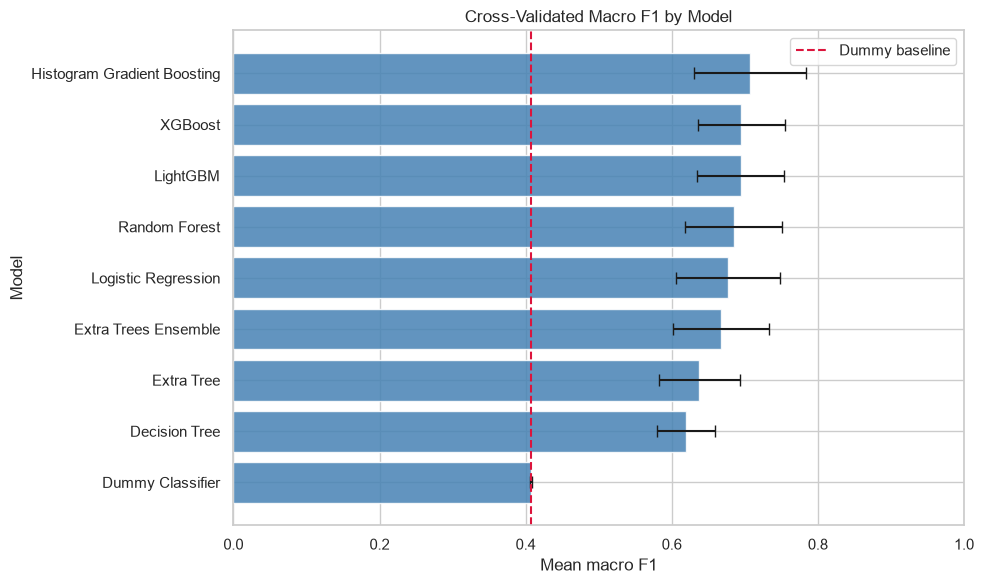

In [83]:
plot_data = model_comparison.sort_values(
    "macro_f1_mean",
    ascending=True,
)

baseline_macro_f1 = model_comparison.loc[
    model_comparison["model"].eq("Dummy Classifier"),
    "macro_f1_mean",
].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_data["model"],
    plot_data["macro_f1_mean"],
    xerr=plot_data["macro_f1_std"],
    color="steelblue",
    alpha=0.85,
    capsize=4,
)

ax.axvline(
    baseline_macro_f1,
    color="crimson",
    linestyle="--",
    label="Dummy baseline",
)

ax.set(
    title="Cross-Validated Macro F1 by Model",
    xlabel="Mean macro F1",
    ylabel="Model",
    xlim=(0, 1),
)

ax.legend()
plt.tight_layout()
plt.show()

## 8.5 Compare Approval and Rejection Recall

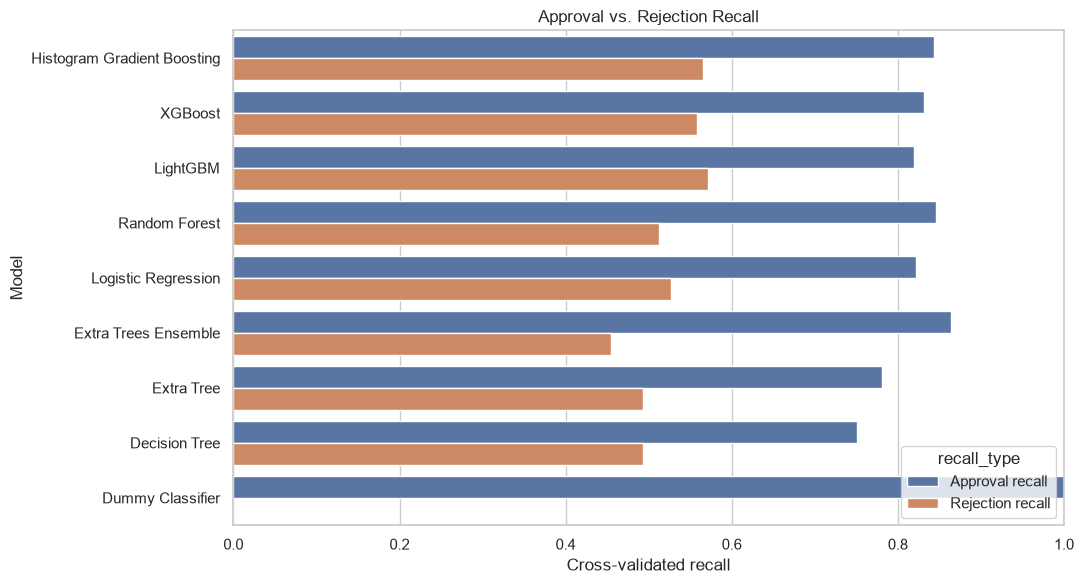

In [84]:
recall_comparison = (
    model_comparison[
        [
            "model",
            "approval_recall_mean",
            "rejection_recall_mean",
        ]
    ]
    .melt(
        id_vars="model",
        var_name="recall_type",
        value_name="recall",
    )
)

recall_comparison["recall_type"] = (
    recall_comparison["recall_type"]
    .replace({
        "approval_recall_mean": "Approval recall",
        "rejection_recall_mean": "Rejection recall",
    })
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=recall_comparison,
    x="recall",
    y="model",
    hue="recall_type",
    ax=ax,
)

ax.set(
    title="Approval vs. Rejection Recall",
    xlabel="Cross-validated recall",
    ylabel="Model",
    xlim=(0, 1),
)

plt.tight_layout()
plt.show()

## 8.6 Seleect the Leading Candiate

In [85]:
real_model_results = model_comparison.loc[
    model_comparison["model"].ne("Dummy Classifier")
]

best_model_name = real_model_results.iloc[0]["model"]
best_pipeline = candidate_pipelines[best_model_name]

print(f"Leading model by macro F1: {best_model_name}")
print(
    "Mean macro F1:",
    round(real_model_results.iloc[0]["macro_f1_mean"], 3),
)
print(
    "Mean rejection recall:",
    round(real_model_results.iloc[0]["rejection_recall_mean"], 3),
)
print(
    "Mean approval recall:",
    round(real_model_results.iloc[0]["approval_recall_mean"], 3),
)

Leading model by macro F1: Histogram Gradient Boosting
Mean macro F1: 0.707
Mean rejection recall: 0.565
Mean approval recall: 0.843


## 9 Tune Histogram Gradient Boosting Using Optuna

The leading Histogram Gradient Boosting model is optimized with Optuna.

Each parameter combination is evaluated through the same stratified
cross-validation procedure used during model comparison. Macro F1 remains the
optimization objective, and the holdout test set remains untouched.

In [86]:
def hgb_objective(trial):
    trial_parameters = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True,
        ),
        "max_iter": trial.suggest_int(
            "max_iter",
            100,
            500,
            step=50,
        ),
        "max_leaf_nodes": trial.suggest_int(
            "max_leaf_nodes",
            7,
            63,
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            5,
            50,
        ),
        "l2_regularization": trial.suggest_float(
            "l2_regularization",
            1e-6,
            10.0,
            log=True,
        ),
    }

    estimator = HistGradientBoostingClassifier(
        **trial_parameters,
        class_weight="balanced",
        early_stopping=False,
        random_state=RANDOM_STATE,
    )

    trial_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

    trial_results = cross_validate(
        estimator=trial_pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring={"macro_f1": "f1_macro"},
        n_jobs=-1,
        error_score="raise",
    )

    fold_scores = trial_results["test_macro_f1"]

    trial.set_user_attr(
        "macro_f1_std",
        float(fold_scores.std()),
    )

    return float(fold_scores.mean())

### 9.2 Run the Optuna Study

In [87]:
optuna_sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
)

hgb_study = optuna.create_study(
    study_name="hgb-macro-f1-optimization",
    direction="maximize",
    sampler=optuna_sampler,
)

hgb_study.optimize(
    hgb_objective,
    n_trials=N_TRIALS,
    gc_after_trial=True,
    show_progress_bar=True,
)

  0%|          | 0/20 [00:00<?, ?it/s]

### 9.3 Inspect the Best parameters

In [88]:
print(f"Best trial: {hgb_study.best_trial.number}")
print(f"Best macro F1: {hgb_study.best_value:.3f}")
print(
    "Cross-validation standard deviation:",
    round(
        hgb_study.best_trial.user_attrs["macro_f1_std"],
        3,
    ),
)

print("\nBest parameters:")

for parameter, value in hgb_study.best_params.items():
    print(f"  {parameter}: {value}")

Best trial: 14
Best macro F1: 0.706
Cross-validation standard deviation: 0.057

Best parameters:
  learning_rate: 0.026430310399522455
  max_iter: 450
  max_leaf_nodes: 50
  min_samples_leaf: 41
  l2_regularization: 0.11919786288173274


### 9.4 Visualize the Optimaization History

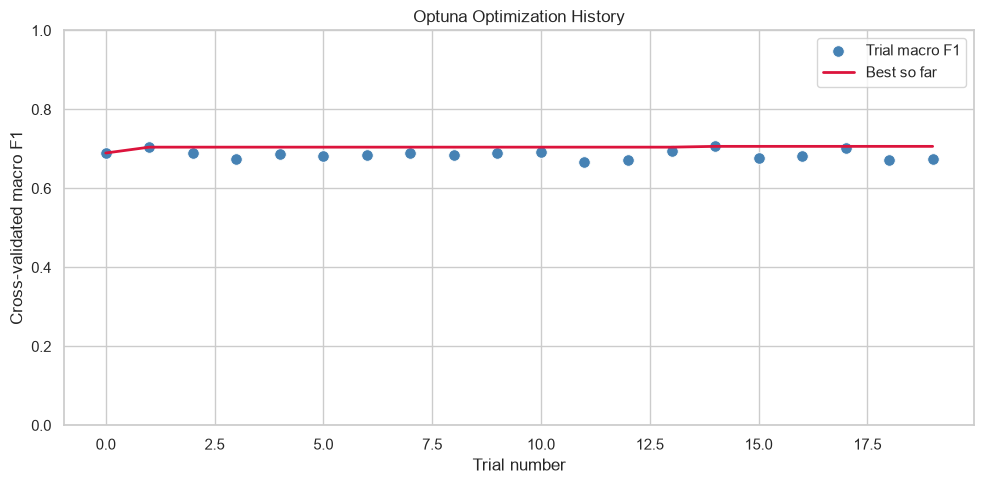

In [89]:
optimization_history = hgb_study.trials_dataframe(
    attrs=("number", "value", "state")
)

optimization_history = optimization_history.loc[
    optimization_history["state"].eq("COMPLETE")
].copy()

optimization_history["best_so_far"] = (
    optimization_history["value"].cummax()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=optimization_history,
    x="number",
    y="value",
    color="steelblue",
    s=70,
    label="Trial macro F1",
    ax=ax,
)

sns.lineplot(
    data=optimization_history,
    x="number",
    y="best_so_far",
    color="crimson",
    linewidth=2,
    label="Best so far",
    ax=ax,
)

ax.set(
    title="Optuna Optimization History",
    xlabel="Trial number",
    ylabel="Cross-validated macro F1",
    ylim=(0, 1),
)

plt.tight_layout()
plt.show()

### 9.5 Build the Tuned Pipeline

In [90]:
tuned_hgb_model = HistGradientBoostingClassifier(
    **hgb_study.best_params,
    class_weight="balanced",
    early_stopping=False,
    random_state=RANDOM_STATE,
)

tuned_hgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            tuned_hgb_model,
        ),
    ]
)

### Evaluatte all the metrics for the tuned model

In [91]:
tuned_cv_results = cross_validate(
    estimator=tuned_hgb_pipeline,
    X=X_train,
    y=y_train,
    cv=cross_validation,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1,
    error_score="raise",
)

tuned_hgb_fold_scores = pd.DataFrame({
    metric: tuned_cv_results[f"test_{metric}"]
    for metric in scoring_metrics
})

tuned_hgb_summary = (
    tuned_hgb_fold_scores
    .agg(["mean", "std"])
    .T
    .rename(columns={
        "mean": "cv_mean",
        "std": "cv_std",
    })
)

display(tuned_hgb_summary.round(3))

,cv_mean,cv_std
accuracy,0.751,0.046
balanced_accuracy,0.708,0.064
macro_f1,0.706,0.063
roc_auc,0.774,0.087
approval_precision,0.818,0.045
approval_recall,0.825,0.057
rejection_precision,0.608,0.083
rejection_recall,0.591,0.140


### 9.7 Compare Tuned and Untuned Version

In [92]:
untuned_hgb_scores = candidate_fold_scores[
    "Histogram Gradient Boosting"
]

tuning_comparison = pd.DataFrame([
    {
        "version": "Untuned HGB",
        **untuned_hgb_scores.mean().to_dict(),
        "macro_f1_std": untuned_hgb_scores["macro_f1"].std(),
    },
    {
        "version": "Tuned HGB",
        **tuned_hgb_fold_scores.mean().to_dict(),
        "macro_f1_std": tuned_hgb_fold_scores["macro_f1"].std(),
    },
])

comparison_columns = [
    "version",
    "macro_f1",
    "macro_f1_std",
    "balanced_accuracy",
    "roc_auc",
    "rejection_recall",
    "approval_recall",
    "accuracy",
]

display(tuning_comparison[comparison_columns].round(3))

,version,macro_f1,macro_f1_std,balanced_accuracy,roc_auc,rejection_recall,approval_recall,accuracy
0,Untuned HGB,0.707,0.077,0.704,0.761,0.565,0.843,0.756
1,Tuned HGB,0.706,0.063,0.708,0.774,0.591,0.825,0.751


### 9.8 Retan the Better Confguration

In [93]:
untuned_macro_f1 = untuned_hgb_scores["macro_f1"].mean()
tuned_macro_f1 = tuned_hgb_fold_scores["macro_f1"].mean()

if tuned_macro_f1 >= untuned_macro_f1:
    selected_pipeline = tuned_hgb_pipeline
    selected_model_version = "Tuned HGB"
else:
    selected_pipeline = candidate_pipelines[
        "Histogram Gradient Boosting"
    ]
    selected_model_version = "Untuned HGB"

print(f"Selected configuration: {selected_model_version}")

Selected configuration: Untuned HGB


### 9.9 Log the tunning result

In [94]:
with mlflow.start_run(run_name="tuned-histogram-gradient-boosting"):
    mlflow.log_param(
        "model",
        "HistGradientBoostingClassifier",
    )
    mlflow.log_param("optimization_method", "Optuna")
    mlflow.log_param("optimization_metric", "macro_f1")
    mlflow.log_param("number_of_trials", N_TRIALS)
    mlflow.log_param("cv_folds", N_SPLITS)
    mlflow.log_params(hgb_study.best_params)

    for metric in scoring_metrics:
        mlflow.log_metric(
            f"cv_{metric}_mean",
            float(tuned_hgb_fold_scores[metric].mean()),
        )
        mlflow.log_metric(
            f"cv_{metric}_std",
            float(tuned_hgb_fold_scores[metric].std()),
        )

print("Tuning results logged to MLflow.")

Tuning results logged to MLflow.


## 10 Select the classification treshhold

The default probability threshold of 0.50 may not provide the best balance
between approvals and rejections.

Out-of-fold probabilities are generated for both Histogram Gradient Boosting
configurations. Each observation receives a prediction from a model that was
not trained on that observation.

The holdout test set remains untouched.

In [95]:
from sklearn.model_selection import cross_val_predict

In [96]:
threshold_candidate_pipelines = {
    "Untuned HGB": candidate_pipelines[
        "Histogram Gradient Boosting"
    ],
    "Tuned HGB": tuned_hgb_pipeline,
}

oof_probabilities = {}

for model_version, pipeline in threshold_candidate_pipelines.items():
    print(f"Generating probabilities for {model_version}...")

    probabilities = cross_val_predict(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    oof_probabilities[model_version] = probabilities

print("Out-of-fold probability generation complete.")

Generating probabilities for Untuned HGB...
Generating probabilities for Tuned HGB...
Out-of-fold probability generation complete.


### 10.3 Evaluate posssible tresholds

In [97]:
threshold_grid = np.round(
    np.arange(0.05, 0.96, 0.01),
    2,
)

threshold_rows = []

for model_version, probabilities in oof_probabilities.items():
    for threshold in threshold_grid:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_train,
            predictions,
            labels=[0, 1],
        ).ravel()

        threshold_rows.append({
            "model_version": model_version,
            "threshold": threshold,
            "macro_f1": f1_score(
                y_train,
                predictions,
                average="macro",
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_train,
                predictions,
            ),
            "approval_precision": precision_score(
                y_train,
                predictions,
                pos_label=1,
                zero_division=0,
            ),
            "approval_recall": recall_score(
                y_train,
                predictions,
                pos_label=1,
                zero_division=0,
            ),
            "rejection_precision": precision_score(
                y_train,
                predictions,
                pos_label=0,
                zero_division=0,
            ),
            "rejection_recall": recall_score(
                y_train,
                predictions,
                pos_label=0,
                zero_division=0,
            ),
            "false_approvals": int(fp),
            "false_rejections": int(fn),
        })

threshold_results = pd.DataFrame(threshold_rows)

### 10.4 Find the best threshold for each model

In [98]:
optimized_thresholds = (
    threshold_results
    .sort_values(
        [
            "model_version",
            "macro_f1",
            "balanced_accuracy",
        ],
        ascending=[True, False, False],
    )
    .groupby("model_version", as_index=False)
    .head(1)
    .sort_values("macro_f1", ascending=False)
)

display(
    optimized_thresholds[
        [
            "model_version",
            "threshold",
            "macro_f1",
            "balanced_accuracy",
            "approval_precision",
            "approval_recall",
            "rejection_precision",
            "rejection_recall",
            "false_approvals",
            "false_rejections",
        ]
    ].round(3)
)

,model_version,threshold,macro_f1,balanced_accuracy,approval_precision,approval_recall,rejection_precision,rejection_recall,false_approvals,false_rejections
29,Untuned HGB,0.34,0.723,0.709,0.804,0.899,0.702,0.519,74,34
121,Tuned HGB,0.35,0.715,0.699,0.794,0.917,0.725,0.481,80,28


### 10.5 Compare optimized treshhold with 0.50

In [99]:
default_threshold_results = threshold_results.loc[
    threshold_results["threshold"].eq(0.50)
].copy()

default_threshold_results["setting"] = "Default 0.50"

optimized_comparison = optimized_thresholds.copy()
optimized_comparison["setting"] = "Optimized"

threshold_comparison = pd.concat(
    [
        default_threshold_results,
        optimized_comparison,
    ],
    ignore_index=True,
)

display(
    threshold_comparison[
        [
            "model_version",
            "setting",
            "threshold",
            "macro_f1",
            "balanced_accuracy",
            "approval_recall",
            "rejection_recall",
            "false_approvals",
            "false_rejections",
        ]
    ]
    .sort_values(
        ["model_version", "setting"]
    )
    .round(3)
)

,model_version,setting,threshold,macro_f1,balanced_accuracy,approval_recall,rejection_recall,false_approvals,false_rejections
1,Tuned HGB,Default 0.50,0.50,0.709,0.708,0.825,0.591,63,59
3,Tuned HGB,Optimized,0.35,0.715,0.699,0.917,0.481,80,28
0,Untuned HGB,Default 0.50,0.50,0.709,0.704,0.843,0.565,67,53
2,Untuned HGB,Optimized,0.34,0.723,0.709,0.899,0.519,74,34


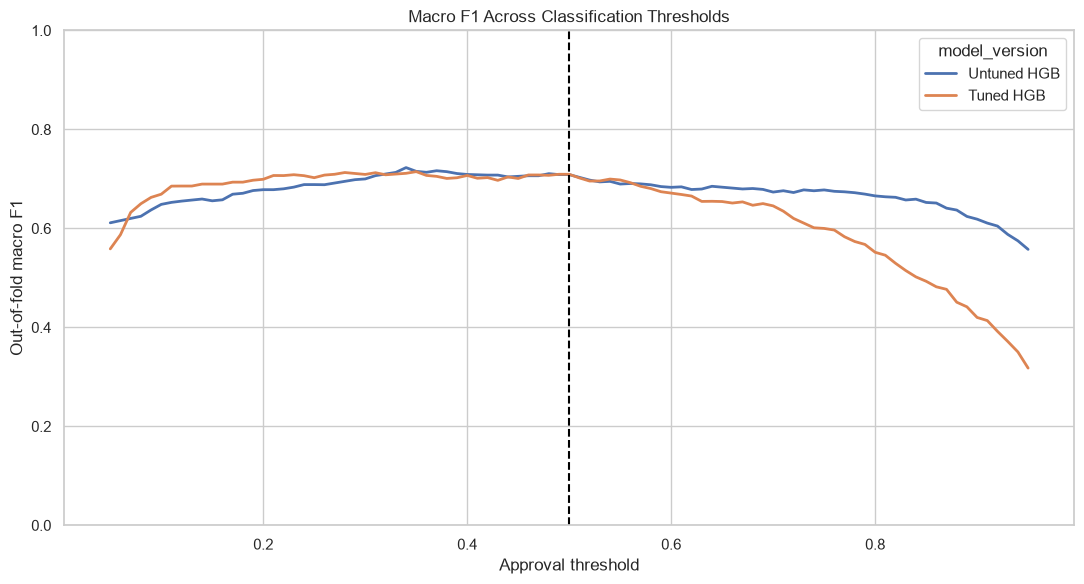

In [100]:
# 10.6 Visualize Macro F1 across Thresholds
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=threshold_results,
    x="threshold",
    y="macro_f1",
    hue="model_version",
    linewidth=2,
    ax=ax,
)

ax.axvline(
    0.50,
    color="black",
    linestyle="--",
    label="Default threshold",
)

ax.set(
    title="Macro F1 Across Classification Thresholds",
    xlabel="Approval threshold",
    ylabel="Out-of-fold macro F1",
    ylim=(0, 1),
)

plt.tight_layout()
plt.show()

In [101]:
# 10.7 Select the best model-threshold combination
best_threshold_row = optimized_thresholds.iloc[0]

selected_model_version = best_threshold_row["model_version"]
selected_threshold = float(best_threshold_row["threshold"])

selected_pipeline = threshold_candidate_pipelines[
    selected_model_version
]

selected_oof_probabilities = oof_probabilities[
    selected_model_version
]

selected_oof_predictions = (
    selected_oof_probabilities >= selected_threshold
).astype(int)

print(f"Selected model: {selected_model_version}")
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"OOF macro F1: {best_threshold_row['macro_f1']:.3f}")
print(
    "OOF rejection recall:",
    round(best_threshold_row["rejection_recall"], 3),
)
print(
    "OOF approval recall:",
    round(best_threshold_row["approval_recall"], 3),
)

Selected model: Untuned HGB
Selected threshold: 0.34
OOF macro F1: 0.723
OOF rejection recall: 0.519
OOF approval recall: 0.899


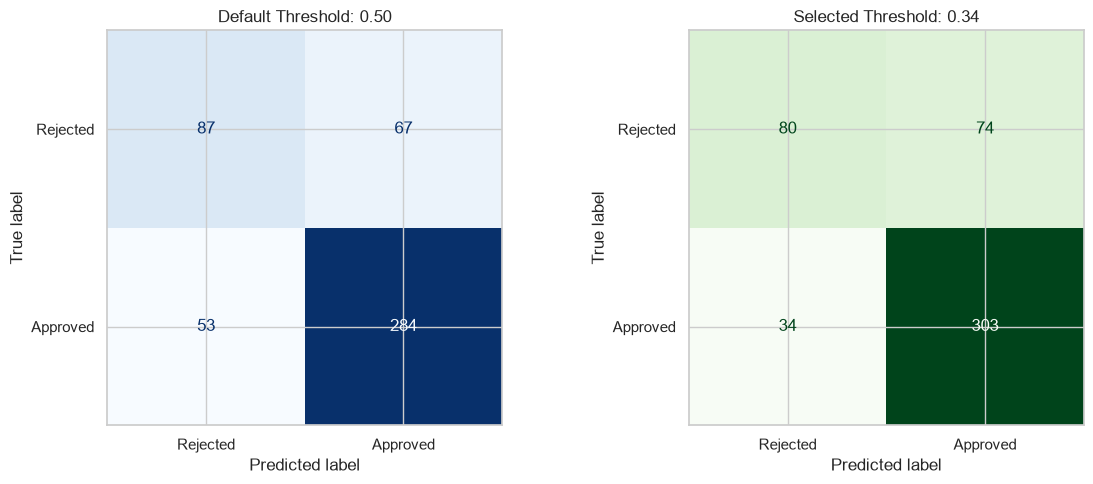

In [102]:
# 10.8 Compare Confusion Matrrics
default_oof_predictions = (
    selected_oof_probabilities >= 0.50
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    default_oof_predictions,
    labels=[0, 1],
    display_labels=["Rejected", "Approved"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)

axes[0].set_title("Default Threshold: 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    selected_oof_predictions,
    labels=[0, 1],
    display_labels=["Rejected", "Approved"],
    cmap="Greens",
    colorbar=False,
    ax=axes[1],
)

axes[1].set_title(
    f"Selected Threshold: {selected_threshold:.2f}"
)

plt.tight_layout()
plt.show()

In [103]:
# 10.9 Log the Decission
with mlflow.start_run(
    run_name="classification-threshold-selection"
):
    mlflow.log_param(
        "selected_model_version",
        selected_model_version,
    )
    mlflow.log_param(
        "selected_threshold",
        selected_threshold,
    )
    mlflow.log_param(
        "selection_metric",
        "out_of_fold_macro_f1",
    )

    mlflow.log_metric(
        "oof_macro_f1",
        float(best_threshold_row["macro_f1"]),
    )
    mlflow.log_metric(
        "oof_balanced_accuracy",
        float(best_threshold_row["balanced_accuracy"]),
    )
    mlflow.log_metric(
        "oof_approval_recall",
        float(best_threshold_row["approval_recall"]),
    )
    mlflow.log_metric(
        "oof_rejection_recall",
        float(best_threshold_row["rejection_recall"]),
    )

print("Threshold-selection results logged to MLflow.")

Threshold-selection results logged to MLflow.


## 11 — Feature importance and fairness audit

Cross-validated permutation importance measures how strongly each original
feature affects macro F1 under the selected classification threshold.

Out-of-fold predictions are also examined across demographic groups. These
results are diagnostic and cannot certify that the model is legally or ethically
fair.

In [104]:
def threshold_macro_f1_scorer(
    estimator,
    features,
    target,
):
    probabilities = estimator.predict_proba(features)[:, 1]

    predictions = (
        probabilities >= selected_threshold
    ).astype(int)

    return f1_score(
        target,
        predictions,
        average="macro",
    )

In [105]:
fold_importance_rows = []

for fold_number, (fit_indices, validation_indices) in enumerate(
    cross_validation.split(X_train, y_train),
    start=1,
):
    X_fit = X_train.iloc[fit_indices]
    y_fit = y_train.iloc[fit_indices]

    X_validation = X_train.iloc[validation_indices]
    y_validation = y_train.iloc[validation_indices]

    fold_pipeline = clone(selected_pipeline)

    fold_pipeline.fit(
        X_fit,
        y_fit,
    )

    fold_importance = permutation_importance(
        estimator=fold_pipeline,
        X=X_validation,
        y=y_validation,
        scoring=threshold_macro_f1_scorer,
        n_repeats=20,
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
    )

    for feature, importance in zip(
        X_train.columns,
        fold_importance.importances_mean,
    ):
        fold_importance_rows.append({
            "fold": fold_number,
            "feature": feature,
            "importance": importance,
        })

fold_importance_results = pd.DataFrame(
    fold_importance_rows
)


In [106]:
permutation_importance_summary = (
    fold_importance_results
    .groupby("feature")["importance"]
    .agg(["mean", "std"])
    .rename(columns={
        "mean": "importance_mean",
        "std": "importance_std",
    })
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index()
)

display(
    permutation_importance_summary.round(4)
)

,feature,importance_mean,importance_std
0,Credit_History,0.1884,0.0569
1,ApplicantIncome,0.0458,0.0205
2,LoanAmount,0.0391,0.0277
3,CoapplicantIncome,0.0373,0.0148
4,Property_Area,0.0313,0.0270
5,Dependents,0.0157,0.0113
6,Education,0.0120,0.0127
7,Gender,0.0103,0.0116
8,Self_Employed,0.0042,0.0072
9,Married,0.0026,0.0065


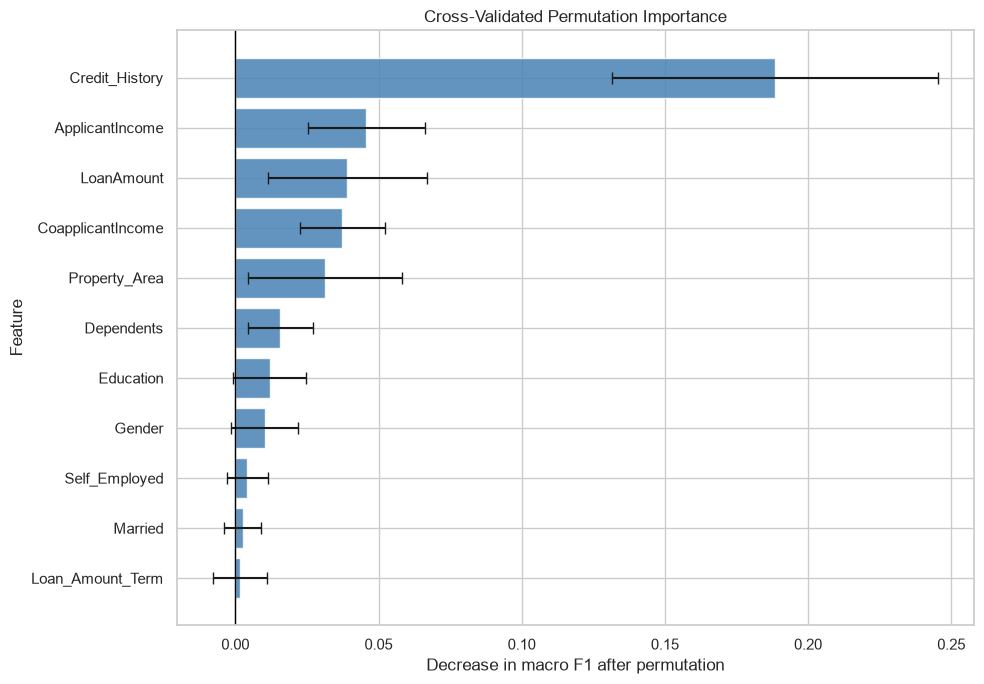

In [107]:
importance_plot_data = (
    permutation_importance_summary
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    importance_plot_data["feature"],
    importance_plot_data["importance_mean"],
    xerr=importance_plot_data["importance_std"],
    color="steelblue",
    alpha=0.85,
    capsize=4,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
)

ax.set(
    title="Cross-Validated Permutation Importance",
    xlabel="Decrease in macro F1 after permutation",
    ylabel="Feature",
)

plt.tight_layout()
plt.show()

In [108]:
# 11.2 Build the fairness-audit dataset
fairness_data = X_train[
    [
        "Gender",
        "Married",
        "Education",
        "Property_Area",
    ]
].copy()

fairness_data["actual"] = y_train.to_numpy()
fairness_data["predicted"] = selected_oof_predictions
fairness_data["approval_score"] = selected_oof_probabilities

for column in [
    "Gender",
    "Married",
    "Education",
    "Property_Area",
]:
    fairness_data[column] = (
        fairness_data[column]
        .astype("string")
        .fillna("Missing")
    )

display(fairness_data.head())

column,Gender,Married,Education,Property_Area,actual,predicted,approval_score
0,Male,No,Graduate,Urban,1,1,0.956584
1,Male,Yes,Graduate,Semiurban,1,1,0.993048
2,Male,Yes,Graduate,Rural,0,0,0.296653
3,Male,Yes,Not Graduate,Rural,0,0,0.004591
4,Male,Yes,Graduate,Semiurban,1,1,0.999077


In [109]:
# 11.3 Calculate Group Level  Metrcs
def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan

    return numerator / denominator

In [110]:
fairness_columns = [
    "Gender",
    "Married",
    "Education",
    "Property_Area",
]

fairness_rows = []

for attribute in fairness_columns:
    for group, group_data in fairness_data.groupby(
        attribute,
        dropna=False,
    ):
        tn, fp, fn, tp = confusion_matrix(
            group_data["actual"],
            group_data["predicted"],
            labels=[0, 1],
        ).ravel()

        fairness_rows.append({
            "attribute": attribute,
            "group": group,
            "support": len(group_data),

            "historical_approval_rate": (
                group_data["actual"].mean()
            ),
            "predicted_approval_rate": (
                group_data["predicted"].mean()
            ),

            "approval_recall": safe_divide(
                tp,
                tp + fn,
            ),
            "rejection_recall": safe_divide(
                tn,
                tn + fp,
            ),

            "false_approval_rate": safe_divide(
                fp,
                fp + tn,
            ),
            "false_rejection_rate": safe_divide(
                fn,
                fn + tp,
            ),
        })

fairness_summary = pd.DataFrame(fairness_rows)

display(
    fairness_summary.round(3)
)

,attribute,group,support,historical_approval_rate,predicted_approval_rate,approval_recall,rejection_recall,false_approval_rate,false_rejection_rate
0,Gender,Female,87,0.701,0.805,0.918,0.462,0.538,0.082
1,Gender,Male,393,0.684,0.761,0.892,0.524,0.476,0.108
2,Gender,Missing,11,0.636,0.727,1.000,0.750,0.250,0.000
3,Married,Missing,3,1.000,1.000,1.000,NaN,NaN,0.000
4,Married,No,169,0.645,0.763,0.899,0.483,0.517,0.101
5,Married,Yes,319,0.705,0.768,0.898,0.543,0.457,0.102
6,Education,Graduate,380,0.708,0.779,0.900,0.514,0.486,0.100
7,Education,Not Graduate,111,0.613,0.730,0.897,0.535,0.465,0.103
8,Property_Area,Rural,145,0.607,0.703,0.898,0.596,0.404,0.102
9,Property_Area,Semiurban,184,0.777,0.864,0.930,0.366,0.634,0.070


In [111]:
# 11.4 Calculate group Disparities
fairness_gap_summary = (
    fairness_summary
    .groupby("attribute")
    .agg(
        predicted_approval_rate_gap=(
            "predicted_approval_rate",
            lambda values: values.max() - values.min(),
        ),
        approval_recall_gap=(
            "approval_recall",
            lambda values: values.max() - values.min(),
        ),
        rejection_recall_gap=(
            "rejection_recall",
            lambda values: values.max() - values.min(),
        ),
    )
    .mul(100)
    .reset_index()
)

display(
    fairness_gap_summary.round(2)
)

,attribute,predicted_approval_rate_gap,approval_recall_gap,rejection_recall_gap
0,Education,4.92,0.26,2.14
1,Gender,7.73,10.78,28.85
2,Married,23.67,10.22,5.92
3,Property_Area,16.07,7.16,23.06


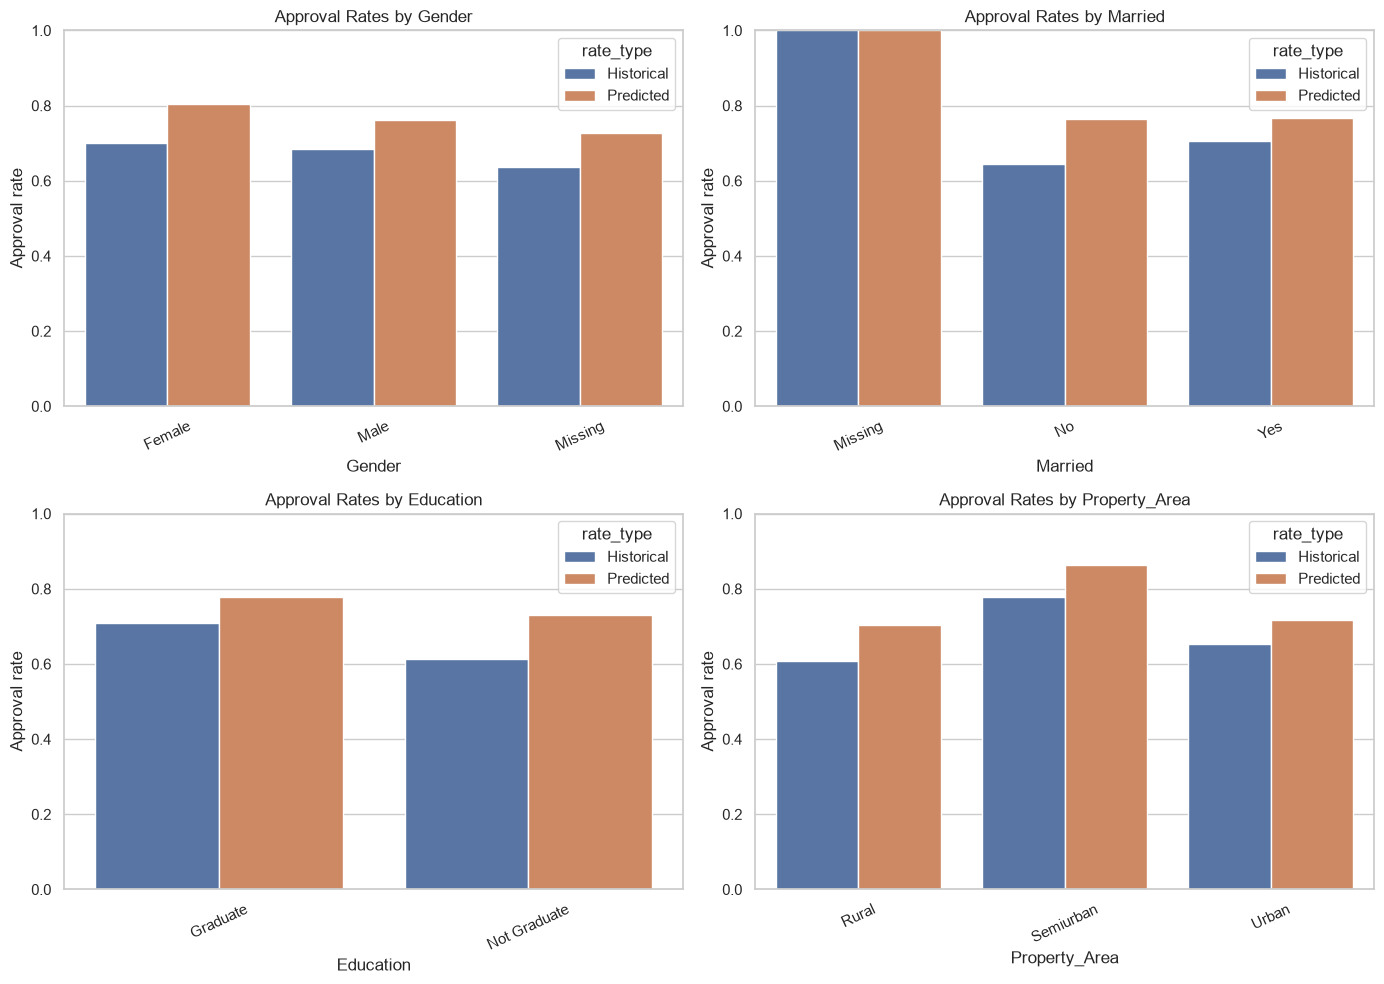

In [112]:
# 11.5 Visualize actual and Predicted Approval Rates
approval_rate_plot = fairness_summary[
    [
        "attribute",
        "group",
        "historical_approval_rate",
        "predicted_approval_rate",
    ]
].melt(
    id_vars=["attribute", "group"],
    var_name="rate_type",
    value_name="approval_rate",
)

approval_rate_plot["rate_type"] = (
    approval_rate_plot["rate_type"]
    .replace({
        "historical_approval_rate": "Historical",
        "predicted_approval_rate": "Predicted",
    })
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
)

for ax, attribute in zip(
    axes.flatten(),
    fairness_columns,
):
    attribute_data = approval_rate_plot.loc[
        approval_rate_plot["attribute"].eq(attribute)
    ]

    sns.barplot(
        data=attribute_data,
        x="group",
        y="approval_rate",
        hue="rate_type",
        ax=ax,
    )

    ax.set(
        title=f"Approval Rates by {attribute}",
        xlabel=attribute,
        ylabel="Approval rate",
        ylim=(0, 1),
    )

    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

# 12 Final Holdout Evaluation

The selected model is fitted on the complete training dataset and evaluated once
on the untouched holdout set.

The classification threshold was selected using out-of-fold training
predictions and will not be adjusted after inspecting the test results.

In [113]:
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
)

In [114]:
final_pipeline = clone(selected_pipeline)

final_pipeline.fit(
    X_train,
    y_train,
)

print(f"Final model: {selected_model_version}")
print(f"Fixed threshold: {selected_threshold:.2f}")
print("Final pipeline fitted on the complete training set.")

Final model: Untuned HGB
Fixed threshold: 0.34
Final pipeline fitted on the complete training set.


In [115]:
# 12.3 Generate holdout predictions
test_probabilities = final_pipeline.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

print(f"Test observations evaluated: {len(y_test)}")

Test observations evaluated: 123


In [116]:
# 12.4 Calulate Final metrics
test_metrics = {
    "accuracy": accuracy_score(
        y_test,
        test_predictions,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_predictions,
    ),
    "macro_f1": f1_score(
        y_test,
        test_predictions,
        average="macro",
    ),
    "roc_auc": roc_auc_score(
        y_test,
        test_probabilities,
    ),
    "approval_precision": precision_score(
        y_test,
        test_predictions,
        pos_label=1,
        zero_division=0,
    ),
    "approval_recall": recall_score(
        y_test,
        test_predictions,
        pos_label=1,
        zero_division=0,
    ),
    "rejection_precision": precision_score(
        y_test,
        test_predictions,
        pos_label=0,
        zero_division=0,
    ),
    "rejection_recall": recall_score(
        y_test,
        test_predictions,
        pos_label=0,
        zero_division=0,
    ),
    "brier_score": brier_score_loss(
        y_test,
        test_probabilities,
    ),
    "log_loss": log_loss(
        y_test,
        test_probabilities,
    ),
}

test_metrics_table = (
    pd.Series(test_metrics, name="test_value")
    .to_frame()
)

display(test_metrics_table.round(3))

,test_value
accuracy,0.821
balanced_accuracy,0.769
macro_f1,0.780
roc_auc,0.790
approval_precision,0.846
approval_recall,0.906
rejection_precision,0.750
rejection_recall,0.632
brier_score,0.165
log_loss,0.665


In [117]:
# 12.5 Display the Classification Report
test_classification_report = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        labels=[0, 1],
        target_names=["Rejected", "Approved"],
        output_dict=True,
        zero_division=0,
    )
).T

display(test_classification_report.round(3))

,precision,recall,f1-score,support
Rejected,0.750,0.632,0.686,38.000
Approved,0.846,0.906,0.875,85.000
accuracy,0.821,0.821,0.821,0.821
macro avg,0.798,0.769,0.780,123.000
weighted avg,0.816,0.821,0.817,123.000


In [118]:
# 12.6 Examine the final confusion matrix
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
)

tn, fp, fn, tp = test_confusion_matrix.ravel()

print(f"Correct rejections: {tn}")
print(f"False approvals:    {fp}")
print(f"False rejections:   {fn}")
print(f"Correct approvals:  {tp}")

Correct rejections: 24
False approvals:    14
False rejections:   8
Correct approvals:  77


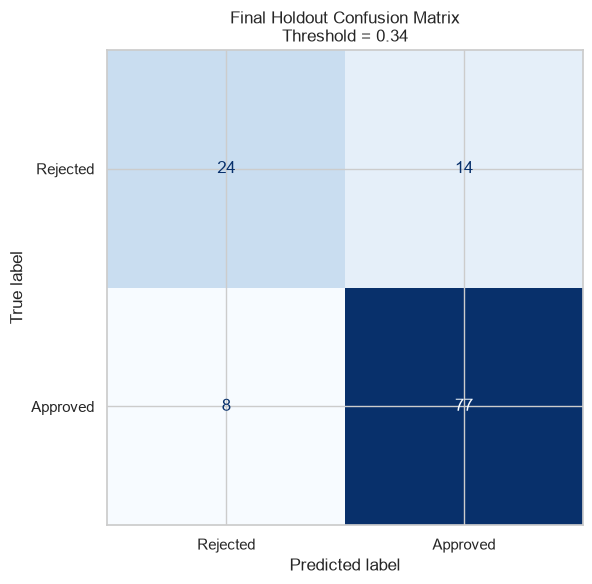

In [119]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=["Rejected", "Approved"],
).plot(
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title(
    f"Final Holdout Confusion Matrix\n"
    f"Threshold = {selected_threshold:.2f}"
)

plt.tight_layout()
plt.show()

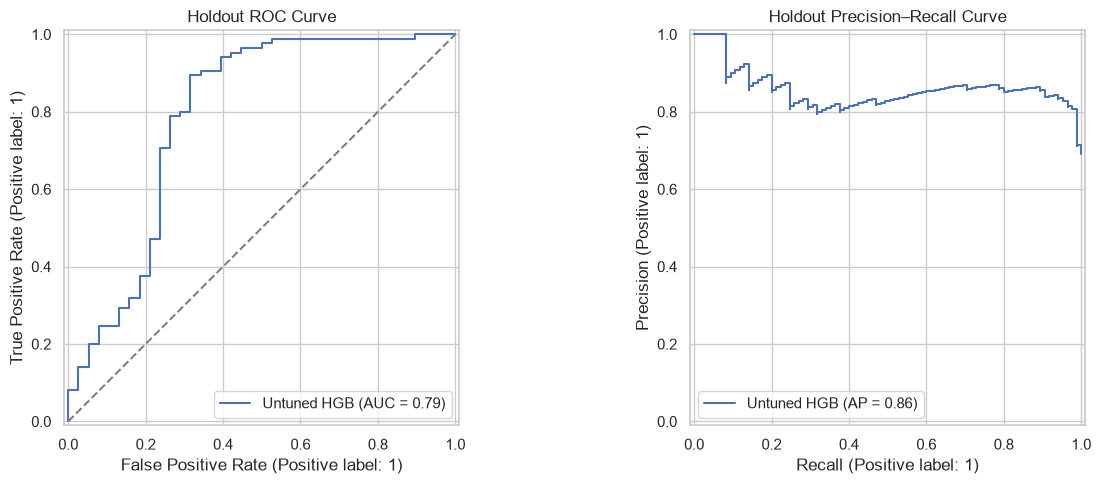

In [120]:
# 12.7 Plot ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_model_version,
    ax=axes[0],
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
)

axes[0].set_title("Holdout ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_model_version,
    ax=axes[1],
)

axes[1].set_title("Holdout Precision–Recall Curve")

plt.tight_layout()
plt.show()

In [121]:
# 12.8 Compare validation and Test Performance
oof_metrics = {
    "accuracy": accuracy_score(
        y_train,
        selected_oof_predictions,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_train,
        selected_oof_predictions,
    ),
    "macro_f1": f1_score(
        y_train,
        selected_oof_predictions,
        average="macro",
    ),
    "roc_auc": roc_auc_score(
        y_train,
        selected_oof_probabilities,
    ),
    "approval_recall": recall_score(
        y_train,
        selected_oof_predictions,
        pos_label=1,
    ),
    "rejection_recall": recall_score(
        y_train,
        selected_oof_predictions,
        pos_label=0,
    ),
}

generalization_comparison = pd.DataFrame(
    {
        "Out-of-fold validation": oof_metrics,
        "Holdout test": {
            metric: test_metrics[metric]
            for metric in oof_metrics
        },
    }
).T

display(generalization_comparison.round(3))

,accuracy,balanced_accuracy,macro_f1,roc_auc,approval_recall,rejection_recall
Out-of-fold validation,0.780,0.709,0.723,0.757,0.899,0.519
Holdout test,0.821,0.769,0.780,0.790,0.906,0.632


In [122]:
# 12.9 Log the Final Evaluation
with mlflow.start_run(
    run_name="final-holdout-evaluation"
):
    mlflow.log_param(
        "model_version",
        selected_model_version,
    )
    mlflow.log_param(
        "classification_threshold",
        selected_threshold,
    )
    mlflow.log_param(
        "test_size",
        len(y_test),
    )

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            float(metric_value),
        )

print("Final holdout results logged to MLflow.")

Final holdout results logged to MLflow.


# 13 Save and verify the final Model artifact

The fitted preprocessing pipeline, classifier, classification threshold, input
schema, and label definitions are packaged together.

A separate JSON file records model performance, environment versions, checksum,
and known limitations.

In [123]:
import hashlib

from datetime import datetime, timezone
from importlib.metadata import version

In [124]:
MODEL_VERSION = "1.0.0"

MODEL_ARTIFACT_PATH = (
    ARTIFACT_DIR / "loan_approval_model.joblib"
)

MODEL_METADATA_PATH = (
    ARTIFACT_DIR / "loan_approval_model_metadata.json"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

model_bundle = {
    "model_version": MODEL_VERSION,
    "pipeline": final_pipeline,
    "classification_threshold": float(
        selected_threshold
    ),
    "selected_configuration": selected_model_version,
    "feature_columns": list(X_train.columns),
    "target_column": TARGET,
    "id_column": ID_COLUMN,
    "target_mapping": TARGET_MAPPING,
    "positive_label": POSITIVE_LABEL,
    "negative_label": NEGATIVE_LABEL,
}

In [125]:
# Save the Fited Pipeline
joblib.dump(
    model_bundle,
    MODEL_ARTIFACT_PATH,
    compress=3,
)

print(f"Model saved to: {MODEL_ARTIFACT_PATH.resolve()}")
print(
    f"Artifact size: "
    f"{MODEL_ARTIFACT_PATH.stat().st_size / 1024:.2f} KB"
)

Model saved to: C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Loan Approval Predcitor (PJ 5)\loan_approval_predictor\artifacts\loan_approval_model.joblib
Artifact size: 162.18 KB


In [126]:
# 13.4 Calculate an artifact checksum
model_checksum = hashlib.sha256(
    MODEL_ARTIFACT_PATH.read_bytes()
).hexdigest()

print(f"SHA-256: {model_checksum}")

SHA-256: 55829fe0392b66bb8823343561f6c260c919723bd32250efb89a8ac839f3d560


In [127]:
# 13.5 Create human-redable metadata
model_metadata = {
    "model_name": "Loan Approval Predictor",
    "model_version": MODEL_VERSION,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "model_class": (
        final_pipeline
        .named_steps["model"]
        .__class__
        .__name__
    ),

    "selected_configuration": selected_model_version,
    "classification_threshold": float(
        selected_threshold
    ),

    "training_rows": int(len(X_train)),
    "holdout_rows": int(len(X_test)),

    "feature_columns": list(X_train.columns),

    "input_schema": {
        column: str(X_train[column].dtype)
        for column in X_train.columns
    },

    "target": {
        "column": TARGET,
        "negative_class": {
            "encoded_value": 0,
            "original_label": NEGATIVE_LABEL,
            "meaning": "Rejected",
        },
        "positive_class": {
            "encoded_value": 1,
            "original_label": POSITIVE_LABEL,
            "meaning": "Approved",
        },
    },

    "holdout_metrics": {
        metric: float(value)
        for metric, value in test_metrics.items()
    },

    "environment": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
        "mlflow": mlflow.__version__,
        "lightgbm": lgb.__version__,
        "xgboost": version("xgboost"),
        "optuna": optuna.__version__,
    },

    "artifact": {
        "filename": MODEL_ARTIFACT_PATH.name,
        "sha256": model_checksum,
    },

    "limitations": [
        "The target represents historical approval decisions, not repayment or default.",
        "The dataset contains only 614 applications.",
        "Historical labels may contain institutional or demographic bias.",
        "Group-level fairness estimates are uncertain for small groups.",
        "Predicted scores are not guaranteed to be calibrated probabilities.",
        "The model must be used as decision support, not autonomous lending approval.",
    ],
}

In [128]:
MODEL_METADATA_PATH.write_text(
    json.dumps(
        model_metadata,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(
    f"Metadata saved to: "
    f"{MODEL_METADATA_PATH.resolve()}"
)

Metadata saved to: C:\Users\Sayed Al Rafi\Documents\Data Desktop\Data_Analysis\ML project\Loan Approval Predcitor (PJ 5)\loan_approval_predictor\artifacts\loan_approval_model_metadata.json


In [129]:
# 13.6 Reload and verify the artifact
loaded_bundle = joblib.load(
    MODEL_ARTIFACT_PATH
)

required_bundle_keys = {
    "pipeline",
    "classification_threshold",
    "feature_columns",
    "target_mapping",
    "positive_label",
    "negative_label",
}

missing_bundle_keys = (
    required_bundle_keys - set(loaded_bundle)
)

if missing_bundle_keys:
    raise ValueError(
        f"Model bundle is missing keys: "
        f"{sorted(missing_bundle_keys)}"
    )

loaded_pipeline = loaded_bundle["pipeline"]

loaded_threshold = loaded_bundle[
    "classification_threshold"
]

loaded_test_probabilities = (
    loaded_pipeline.predict_proba(X_test)[:, 1]
)

loaded_test_predictions = (
    loaded_test_probabilities >= loaded_threshold
).astype(int)

np.testing.assert_allclose(
    loaded_test_probabilities,
    test_probabilities,
)

np.testing.assert_array_equal(
    loaded_test_predictions,
    test_predictions,
)

print("Artifact reload verification passed.")
print("Probabilities match the evaluated model.")
print("Class predictions match the evaluated model.")

Artifact reload verification passed.
Probabilities match the evaluated model.
Class predictions match the evaluated model.


In [130]:
# 13.7 Log the artifact to MLflow
with mlflow.start_run(
    run_name="final-model-artifacts"
):
    mlflow.log_param("model_version", MODEL_VERSION)
    mlflow.log_param(
        "classification_threshold",
        selected_threshold,
    )
    mlflow.log_param(
        "model_sha256",
        model_checksum,
    )

    mlflow.log_artifact(
        str(MODEL_ARTIFACT_PATH)
    )
    mlflow.log_artifact(
        str(MODEL_METADATA_PATH)
    )

print("Final artifacts logged to MLflow.")

Final artifacts logged to MLflow.


# 14 Create a validate inference function

A production-style inference function loads the saved model bundle, validates
incoming application data, preserves the required feature order, and applies
the stored classification threshold.

The returned approval score is a model score and should not be interpreted as a
guaranteed probability of approval or repayment.

In [131]:
# 14.1 Load the production bundle
production_bundle = joblib.load(
    MODEL_ARTIFACT_PATH
)

production_pipeline = production_bundle["pipeline"]

production_threshold = production_bundle[
    "classification_threshold"
]

production_features = production_bundle[
    "feature_columns"
]

print(
    f"Loaded model version: "
    f"{production_bundle['model_version']}"
)
print(
    f"Classification threshold: "
    f"{production_threshold:.2f}"
)
print(f"Required features: {len(production_features)}")


Loaded model version: 1.0.0
Classification threshold: 0.34
Required features: 11


In [132]:
# 14.2 Define valid input values
ALLOWED_CATEGORIES = {
    "Gender": {"Male", "Female"},
    "Married": {"Yes", "No"},
    "Dependents": {"0", "1", "2", "3+"},
    "Education": {"Graduate", "Not Graduate"},
    "Self_Employed": {"Yes", "No"},
    "Property_Area": {
        "Rural",
        "Semiurban",
        "Urban",
    },
}

NUMERIC_FEATURES = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
]

In [133]:
# 14.3 Create the input validation function
def validate_application(application):
    if not isinstance(application, dict):
        raise TypeError(
            "Application must be provided as a dictionary."
        )

    expected_features = set(production_features)
    provided_features = set(application)

    missing_features = sorted(
        expected_features - provided_features
    )

    unexpected_features = sorted(
        provided_features - expected_features
    )

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    if unexpected_features:
        raise ValueError(
            f"Unexpected features: {unexpected_features}"
        )

    application_frame = pd.DataFrame(
        [application],
        columns=production_features,
    )

    # Treat blank strings as missing values
    application_frame = application_frame.replace(
        r"^\s*$",
        np.nan,
        regex=True,
    )

    # Validate and normalize categorical values
    for column, allowed_values in ALLOWED_CATEGORIES.items():
        value = application_frame.at[0, column]

        if pd.notna(value):
            normalized_value = str(value).strip()

            if normalized_value not in allowed_values:
                raise ValueError(
                    f"Invalid value for {column}: "
                    f"{normalized_value!r}. "
                    f"Expected one of {sorted(allowed_values)}."
                )

            application_frame.at[
                0,
                column,
            ] = normalized_value

    # Convert numerical inputs
    for column in NUMERIC_FEATURES:
        original_value = application_frame.at[0, column]

        if pd.notna(original_value):
            try:
                numeric_value = float(original_value)
            except (TypeError, ValueError) as error:
                raise ValueError(
                    f"{column} must be numeric."
                ) from error

            application_frame.at[
                0,
                column,
            ] = numeric_value

    # Validate numerical ranges
    non_negative_columns = [
        "ApplicantIncome",
        "CoapplicantIncome",
    ]

    for column in non_negative_columns:
        value = application_frame.at[0, column]

        if pd.notna(value) and value < 0:
            raise ValueError(
                f"{column} cannot be negative."
            )

    positive_columns = [
        "LoanAmount",
        "Loan_Amount_Term",
    ]

    for column in positive_columns:
        value = application_frame.at[0, column]

        if pd.notna(value) and value <= 0:
            raise ValueError(
                f"{column} must be greater than zero."
            )

    credit_history = application_frame.at[
        0,
        "Credit_History",
    ]

    if (
        pd.notna(credit_history)
        and credit_history not in {0.0, 1.0}
    ):
        raise ValueError(
            "Credit_History must be 0, 1, or missing."
        )

    # Give numerical columns consistent numeric dtypes
    application_frame[NUMERIC_FEATURES] = (
        application_frame[NUMERIC_FEATURES]
        .apply(pd.to_numeric)
    )

    return application_frame

In [134]:
# 14.4 Create the prediction function
def predict_loan_approval(application):
    application_frame = validate_application(
        application
    )

    approval_score = float(
        production_pipeline.predict_proba(
            application_frame
        )[0, 1]
    )

    predicted_encoded_value = int(
        approval_score >= production_threshold
    )

    if predicted_encoded_value == 1:
        predicted_label = production_bundle[
            "positive_label"
        ]
        prediction = "Approved"
    else:
        predicted_label = production_bundle[
            "negative_label"
        ]
        prediction = "Rejected"

    return {
        "prediction": prediction,
        "predicted_label": predicted_label,
        "encoded_prediction": predicted_encoded_value,
        "approval_score": round(approval_score, 4),
        "classification_threshold": float(
            production_threshold
        ),
        "model_version": production_bundle[
            "model_version"
        ],
    }

In [135]:
# 14.5 Test with a synthetic application
example_application = {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "1",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5_000,
    "CoapplicantIncome": 1_500,
    "LoanAmount": 130,
    "Loan_Amount_Term": 360,
    "Credit_History": 1,
    "Property_Area": "Semiurban",
}

example_prediction = predict_loan_approval(
    example_application
)

display(example_prediction)

{'prediction': 'Approved',
 'predicted_label': 'Y',
 'encoded_prediction': 1,
 'approval_score': 0.9788,
 'classification_threshold': 0.34,
 'model_version': '1.0.0'}

In [136]:
# 14.6 Confirm validation catches bad input
invalid_application = example_application.copy()
invalid_application["Credit_History"] = 4

try:
    predict_loan_approval(invalid_application)
except ValueError as error:
    print(f"Validation correctly rejected the input:")
    print(error)

Validation correctly rejected the input:
Credit_History must be 0, 1, or missing.
